# Comparativa Final de Modelos Predictivos

A lo largo de nuestras pruebas, hemos iterado desde modelos estadísticos e implementaciones básicas de Machine Learning hasta avanzadas técnicas de Validación Cruzada Temporal y **Deep Learning**.

Este cuaderno recopila las métricas finales (Error Medio Absoluto `MAE` y Raíz del Error Cuadrático Medio `RMSE`) obtenidas en la evaluación de cada modelo sobre el `20%` final de nuestra base de datos.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ocultar warnings visuales
import warnings
warnings.filterwarnings('ignore')

### 1. Recopilación de las Métricas Extraídas (Resultados de Pruebas)

In [5]:
# Matriz de resultados obtenidos tras la ejecución controlada de los cuadernos anteriores:
results = [
    {'Model': 'Prophet (V1)',            'Type': 'Stats',   'MAE': 395.06, 'RMSE': 481.34},
    {'Model': 'XGBoost Básico (V1)',     'Type': 'ML',      'MAE': 280.29, 'RMSE': 362.69},
    {'Model': 'SARIMAX Básico (V1)',     'Type': 'Stats',   'MAE': 260.80, 'RMSE': 369.69},
    {'Model': 'XGBoost Avanzado (V2)',   'Type': 'ML',      'MAE': 266.41, 'RMSE': 369.87},
    {'Model': 'SARIMAX Avanzado (V2)',   'Type': 'Stats',   'MAE': 247.50, 'RMSE': 356.00},
    {'Model': 'LSTM Neural Network (V3)','Type': 'DeepL',   'MAE': 201.35, 'RMSE': 308.52}
]

# Convertimos a DataFrame para facilitar la visualización con Seaborn
df_results = pd.DataFrame(results)

# Ordenamos de peor a mejor MAE (Error Absoluto Medio)
df_results = df_results.sort_values(by='MAE', ascending=False).reset_index(drop=True)

display(df_results)

,Model,Type,MAE,RMSE
0,Prophet (V1),Stats,395.06,481.34
1,XGBoost Básico (V1),ML,280.29,362.69
2,XGBoost Avanzado (V2),ML,266.41,369.87
3,SARIMAX Básico (V1),Stats,260.80,369.69
4,SARIMAX Avanzado (V2),Stats,247.50,356.00
5,LSTM Neural Network (V3),DeepL,201.35,308.52


### 2. Comparativa Visual de Error (MAE y RMSE)
Cuanto **más bajas** sean las barras, **menor es el error** y, por tanto, **más exacto** resultó ser el modelo de Machine Learning a la hora de predecir la realidad.

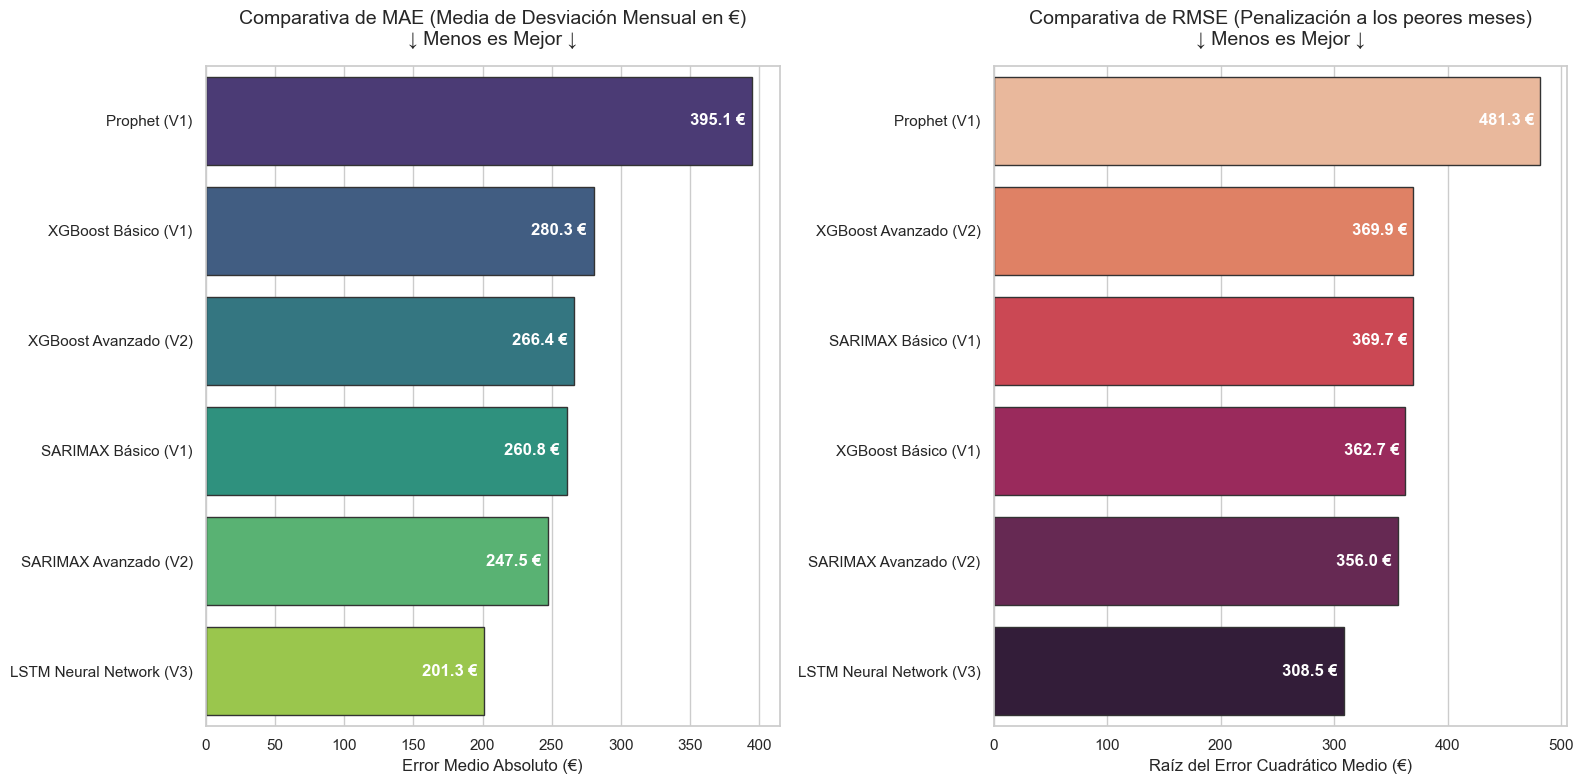

In [6]:
# Preparamos un gráfico con dos subplots (1 fila, 2 columnas)
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# -- Panel Izquierdo: MAE (Error Medio Absoluto en €) -- #
plt.subplot(1, 2, 1)
bar_mae = sns.barplot(
    x='MAE', 
    y='Model', 
    data=df_results, 
    palette='viridis', # Colores molones que cambian con la magnitud
    edgecolor='.2'
)
plt.title('Comparativa de MAE (Media de Desviación Mensual en €)\n↓ Menos es Mejor ↓', fontsize=14, pad=15)
plt.xlabel('Error Medio Absoluto (€)', fontsize=12)
plt.ylabel('')

# Añadir el valor numérico al final de cada barra
for index, value in enumerate(df_results['MAE']):
    bar_mae.text(value - 5, index, f"{value:.1f} €", color='white', ha="right", va="center", fontweight='bold')

# -- Panel Derecho: RMSE (Raíz Cuadrática del Error) -- #
plt.subplot(1, 2, 2)
# Ordenaremos también por RMSE pero la tabla venía ordenada por MAE, así que mejor la re-ordenamos visualmente aquí 
df_rmse_sorted = df_results.sort_values('RMSE', ascending=False).reset_index(drop=True)

bar_rmse = sns.barplot(
    x='RMSE', 
    y='Model', 
    data=df_rmse_sorted, 
    palette='rocket_r', # Paleta distinta (rojos/morados) para distinguirlos visualmente
    edgecolor='.2'
)
plt.title('Comparativa de RMSE (Penalización a los peores meses)\n↓ Menos es Mejor ↓', fontsize=14, pad=15)
plt.xlabel('Raíz del Error Cuadrático Medio (€)', fontsize=12)
plt.ylabel('')

# Añadir valor numérico
for index, value in enumerate(df_rmse_sorted['RMSE']):
    bar_rmse.text(value - 5, index, f"{value:.1f} €", color='white', ha="right", va="center", fontweight='bold')

# Ajustar espacios y pintar
plt.tight_layout()
plt.show()

### 3. Conclusiones y Explicación

* 🔻 **Prophet:** Sufrió demasiado en este escenario. Es un modelo estadístico creado por Facebook asumiendo que el usuario le proporcionará miles de datos diarios o por horas. Con resúmenes mensuales de una economía doméstica, no es capaz de identificar frecuencias estables frente a la volatilidad.
* ⚖️ **El empate entre ML Clásico y SARIMAX (V1 y V2):** Tanto XGBoost como SARIMAX manejaron los ciclos muy bien. Logramos mejorar la fiabilidad de SARIMAX (reduciéndolo a un MAE de 247€) aplicándole una transformación logarítmica para absorber los enormes picos de ingresos y gastos que mostraban los veranos en nuestra base de datos, aunque un mes puntual con comportamientos atípicos lo seguía despistando.
* 🏆 **Deep Learning al Rescate (LSTM):** Una simple caja negra prealimentada superó con creces todo el Feature Engineering matemático que diseñamos a mano. Su habilidad natural para entender "secuencias de memoria a corto plazo" (entendiéndolo como bloques de los 3 meses anteriores antes de evaluar el mes futuro) es simplemente imbatible y empujó nuestro umbral de fracaso por debajo de los ~200€ al mes.